In [58]:
import math
from collections import defaultdict, deque

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd

In [59]:
PLACE = "London, England"
NETWORK_TYPE = "drive"
RANDOM_SEED = 42
SIMULATION_STEPS = 90
CYCLE_TIME = 60
MIN_GREEN = 15
MAX_GREEN = 45
ARRIVAL_RATE = 18
NUM_OD_PAIRS = 40
NUM_TRIALS = 20
BETWEENNESS_K = 80
ALPHA = 0.75
BETA = 0.25

rng = np.random.default_rng(RANDOM_SEED)
ox.settings.use_cache = True

In [60]:
def parse_numeric(value, default):
    if value is None:
        return default
    if isinstance(value, list):
        value = value[0]
    if isinstance(value, str):
        digits = "".join(ch for ch in value if ch.isdigit() or ch == ".")
        return float(digits) if digits else default
    return float(value)


def collapse_multidigraph(multigraph):
    graph = nx.DiGraph()
    for node, data in multigraph.nodes(data=True):
        graph.add_node(node, **data)

    for u, v, data in multigraph.edges(data=True):
        edge_data = dict(data)
        edge_data["length"] = float(edge_data.get("length", 1.0))
        if graph.has_edge(u, v):
            if edge_data["length"] < graph[u][v]["length"]:
                graph[u][v].update(edge_data)
        else:
            graph.add_edge(u, v, **edge_data)

    return graph

In [61]:
raw_graph = ox.graph_from_place(PLACE, network_type=NETWORK_TYPE, simplify=True)
largest_component = max(nx.strongly_connected_components(raw_graph), key=len)
raw_graph = raw_graph.subgraph(largest_component).copy()

G = collapse_multidigraph(raw_graph)
G.graph["crs"] = raw_graph.graph.get("crs")

for u, v, data in G.edges(data=True):
    length = float(data.get("length", 1.0))
    speed_kph = parse_numeric(data.get("maxspeed"), 35.0)
    lanes = max(1, int(round(parse_numeric(data.get("lanes"), 1.0))))
    travel_time = length / max(speed_kph * 1000 / 3600, 1.0)

    data["length"] = length
    data["speed_kph"] = speed_kph
    data["lanes"] = lanes
    data["travel_time"] = travel_time
    data["capacity_per_cycle"] = max(1, int(lanes * 8))

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 130283
Edges: 300324


In [62]:
k_value = min(BETWEENNESS_K, max(10, G.number_of_nodes() - 1))
betweenness = nx.betweenness_centrality(
    G,
    k=k_value,
    normalized=True,
    weight="travel_time",
    seed=RANDOM_SEED,
    endpoints=False,
)

max_bc = max(betweenness.values()) if betweenness else 1.0
node_importance = {
    node: (value / max_bc if max_bc else 0.0)
    for node, value in betweenness.items()
}
nx.set_node_attributes(G, node_importance, "betweenness_norm")

candidate_nodes = [
    node
    for node in G.nodes()
    if G.in_degree(node) > 0 and G.out_degree(node) > 0
]

print(f"Candidate intersections: {len(candidate_nodes)}")

Candidate intersections: 130283


In [63]:
route_bank = []
route_keys = set()
attempts = 0
max_attempts = NUM_OD_PAIRS * 40

while len(route_bank) < NUM_OD_PAIRS and attempts < max_attempts:
    origin, destination = rng.choice(candidate_nodes, size=2, replace=False)
    attempts += 1
    if (origin, destination) in route_keys:
        continue

    try:
        path = nx.shortest_path(G, origin, destination, weight="travel_time")
    except nx.NetworkXNoPath:
        continue

    if len(path) < 4:
        continue

    route_edges = list(zip(path[:-1], path[1:]))
    route_bank.append({
        "origin": origin,
        "destination": destination,
        "path": path,
        "edges": route_edges,
    })
    route_keys.add((origin, destination))

print(f"Routes prepared: {len(route_bank)}")

Routes prepared: 40


In [64]:
def build_demand_schedule(steps, arrival_rate, seed):
    local_rng = np.random.default_rng(seed)
    schedule = []

    for _ in range(steps):
        arrivals = int(local_rng.poisson(arrival_rate))
        if arrivals == 0:
            schedule.append([])
            continue

        chosen_routes = local_rng.integers(0, len(route_bank), size=arrivals)
        schedule.append(chosen_routes.tolist())

    return schedule


demand_schedule = build_demand_schedule(
    SIMULATION_STEPS,
    ARRIVAL_RATE,
    RANDOM_SEED,
)

total_arrivals = sum(len(step) for step in demand_schedule)
print(f"Vehicles scheduled: {total_arrivals}")

Vehicles scheduled: 1646


In [65]:
def make_empty_edge_queues(graph):
    return {edge: deque() for edge in graph.edges()}


def prepare_topology(graph):
    nodes = list(graph.nodes())
    incoming_edges = {node: list(graph.in_edges(node)) for node in nodes}
    outgoing_edges = {node: list(graph.out_edges(node)) for node in nodes}
    node_importance = {
        node: float(graph.nodes[node].get("betweenness_norm", 0.0))
        for node in nodes
    }
    return nodes, incoming_edges, outgoing_edges, node_importance


def downstream_queue_mean(edge_queues, outgoing_edges, node):
    outgoing = outgoing_edges[node]
    if not outgoing:
        return 0.0
    total = 0
    for next_edge in outgoing:
        total += len(edge_queues[next_edge])
    return total / len(outgoing)


def service_capacity(graph, edge, green_time):
    capacity = graph.edges[edge]["capacity_per_cycle"]
    scaled_capacity = capacity * (green_time / CYCLE_TIME)
    return max(1, int(math.floor(scaled_capacity)))

In [66]:
def choose_edge_for_node(
    incoming,
    edge_queues,
    controller,
    step,
    node_importance,
    outgoing_edges,
    alpha=ALPHA,
    beta=BETA,
):
    if not incoming:
        return None, 0

    if controller == "fixed":
        selected_edge = incoming[step % len(incoming)]
        return selected_edge, CYCLE_TIME / max(1, len(incoming))

    if controller == "backpressure":
        best_edge = None
        best_score = -np.inf

        for edge in incoming:
            queue_now = len(edge_queues[edge])
            score = queue_now - downstream_queue_mean(edge_queues, outgoing_edges, edge[1])
            if score > best_score:
                best_score = score
                best_edge = edge

        return best_edge, CYCLE_TIME / max(1, len(incoming))

    if controller == "proposed":
        max_local_queue = max(len(edge_queues[edge]) for edge in incoming) or 1
        best_edge = None
        best_priority = -np.inf

        for edge in incoming:
            load_norm = len(edge_queues[edge]) / max_local_queue
            priority = alpha * load_norm + beta * node_importance
            if priority > best_priority:
                best_priority = priority
                best_edge = edge

        green_time = MIN_GREEN + (MAX_GREEN - MIN_GREEN) * max(0.0, best_priority)
        return best_edge, min(MAX_GREEN, green_time)

    raise ValueError(f"Unknown controller: {controller}")

In [67]:
def run_simulation(
    graph,
    route_bank,
    demand_schedule,
    controller,
    topology=None,
    alpha=ALPHA,
    beta=BETA,
):
    edge_queues = make_empty_edge_queues(graph)
    queue_history = []
    completed_travel_times = []
    total_injected = 0
    node_queue_totals = defaultdict(float)
    node_queue_peaks = defaultdict(int)

    if topology is None:
        topology = prepare_topology(graph)
    nodes, incoming_edges, outgoing_edges, node_importance_map = topology

    for step, arrivals in enumerate(demand_schedule):
        transfers = []

        for node in nodes:
            incoming = incoming_edges[node]
            if not incoming:
                continue

            selected_edge, green_time = choose_edge_for_node(
                incoming=incoming,
                edge_queues=edge_queues,
                controller=controller,
                step=step,
                node_importance=node_importance_map[node],
                outgoing_edges=outgoing_edges,
                alpha=alpha,
                beta=beta,
            )
            if selected_edge is None:
                continue

            move_count = min(
                len(edge_queues[selected_edge]),
                service_capacity(graph, selected_edge, green_time),
            )

            for _ in range(move_count):
                vehicle = edge_queues[selected_edge].popleft()
                transfers.append(vehicle)

        for vehicle in transfers:
            vehicle["edge_pos"] += 1
            route_edges = route_bank[vehicle["route_id"]]["edges"]

            if vehicle["edge_pos"] >= len(route_edges):
                completed_travel_times.append(step - vehicle["start_step"] + 1)
            else:
                next_edge = route_edges[vehicle["edge_pos"]]
                edge_queues[next_edge].append(vehicle)

        for route_id in arrivals:
            first_edge = route_bank[route_id]["edges"][0]
            edge_queues[first_edge].append({
                "route_id": route_id,
                "edge_pos": 0,
                "start_step": step,
            })
            total_injected += 1

        total_queue = 0
        for node in nodes:
            incoming = incoming_edges[node]
            node_queue = 0
            for edge in incoming:
                node_queue += len(edge_queues[edge])
            node_queue_totals[node] += node_queue
            node_queue_peaks[node] = max(node_queue_peaks[node], node_queue)
            total_queue += node_queue

        queue_history.append(total_queue)

    avg_node_queue = {
        node: node_queue_totals[node] / len(demand_schedule)
        for node in nodes
    }

    return {
        "controller": controller,
        "avg_queue_length": float(np.mean(queue_history)) if queue_history else 0.0,
        "avg_travel_time": float(np.mean(completed_travel_times)) if completed_travel_times else np.nan,
        "throughput": len(completed_travel_times),
        "completion_ratio": len(completed_travel_times) / total_injected if total_injected else 0.0,
        "queue_history": queue_history,
        "avg_node_queue": avg_node_queue,
        "peak_node_queue": dict(node_queue_peaks),
    }

In [ ]:
def evaluate_controllers_over_trials(
    graph,
    route_bank,
    controllers,
    num_trials,
    base_seed,
    alpha=ALPHA,
    beta=BETA,
    arrival_rate=ARRIVAL_RATE,
    simulation_steps=SIMULATION_STEPS,
    show_progress=True,
):
    import time

    if not route_bank:
        raise ValueError("route_bank is empty. Generate OD routes before running trials.")

    topology = prepare_topology(graph)
    trial_outputs = {controller: [] for controller in controllers}
    demand_schedules = [
        build_demand_schedule(simulation_steps, arrival_rate, base_seed + trial)
        for trial in range(num_trials)
    ]

    start_time = time.perf_counter()
    for trial_index, demand_schedule_trial in enumerate(demand_schedules, start=1):
        for controller in controllers:
            result = run_simulation(
                graph,
                route_bank,
                demand_schedule_trial,
                controller,
                topology=topology,
                alpha=alpha,
                beta=beta,
            )
            trial_outputs[controller].append(result)

        if show_progress:
            elapsed = time.perf_counter() - start_time
            print(f"Completed trial {trial_index}/{num_trials} in {elapsed:.1f}s")

    results = []
    for controller in controllers:
        runs = trial_outputs[controller]
        queue_histories = np.array([run["queue_history"] for run in runs], dtype=float)
        avg_node_queue = {
            node: float(np.mean([run["avg_node_queue"][node] for run in runs]))
            for node in topology[0]
        }
        peak_node_queue = {
            node: int(np.max([run["peak_node_queue"][node] for run in runs]))
            for node in topology[0]
        }

        travel_times = np.array([run["avg_travel_time"] for run in runs], dtype=float)
        avg_travel_time = float(np.nanmean(travel_times)) if np.any(~np.isnan(travel_times)) else np.nan

        results.append(
            {
                "controller": controller,
                "avg_queue_length": float(np.mean([run["avg_queue_length"] for run in runs])),
                "avg_travel_time": avg_travel_time,
                "throughput": float(np.mean([run["throughput"] for run in runs])),
                "completion_ratio": float(np.mean([run["completion_ratio"] for run in runs])),
                "queue_history": queue_histories.mean(axis=0).tolist(),
                "avg_node_queue": avg_node_queue,
                "peak_node_queue": peak_node_queue,
            }
        )

    metrics_df = pd.DataFrame(
        [
            {
                "Controller": result["controller"],
                "Average Queue Length": round(result["avg_queue_length"], 2),
                "Average Travel Time": round(result["avg_travel_time"], 2),
                "Throughput": round(result["throughput"], 1),
                "Completion Ratio": round(result["completion_ratio"], 3),
            }
            for result in results
        ]
    ).sort_values("Average Queue Length")

    if show_progress:
        total_elapsed = time.perf_counter() - start_time
        print(f"All trials complete in {total_elapsed:.1f}s")

    return results, metrics_df


controllers = ["fixed", "backpressure", "proposed"]
results, metrics_df = evaluate_controllers_over_trials(
    graph=G,
    route_bank=route_bank,
    controllers=controllers,
    num_trials=NUM_TRIALS,
    base_seed=RANDOM_SEED,
    alpha=ALPHA,
    beta=BETA,
    arrival_rate=ARRIVAL_RATE,
    simulation_steps=SIMULATION_STEPS,
    show_progress=True,
)

metrics_df

In [ ]:
print(
    "Methodology note: OSM provides the real road network and road attributes. "
    "Traffic queues and arrivals are simulated, and each controller is evaluated over "
    f"{NUM_TRIALS} trials with different demand realizations before averaging metrics. "
    f"Current proposed-controller weights: alpha={ALPHA}, beta={BETA}."
)

Methodology note: OSM provides the real road network and road attributes. Traffic queues and arrivals are simulated, and each controller is evaluated over 10 trials with different demand realizations before averaging metrics.


In [ ]:
result_by_controller = {result["controller"]: result for result in results}

junction_comparison_df = pd.DataFrame(
    {
        "node": list(G.nodes()),
        "betweenness_norm": [G.nodes[node].get("betweenness_norm", 0.0) for node in G.nodes()],
        "fixed_avg_queue": [
            result_by_controller["fixed"]["avg_node_queue"][node]
            for node in G.nodes()
        ],
        "backpressure_avg_queue": [
            result_by_controller["backpressure"]["avg_node_queue"][node]
            for node in G.nodes()
        ],
        "proposed_avg_queue": [
            result_by_controller["proposed"]["avg_node_queue"][node]
            for node in G.nodes()
        ],
    }
)

junction_comparison_df["reduction_vs_fixed"] = (
    junction_comparison_df["fixed_avg_queue"] - junction_comparison_df["proposed_avg_queue"]
)
junction_comparison_df["reduction_vs_backpressure"] = (
    junction_comparison_df["backpressure_avg_queue"] - junction_comparison_df["proposed_avg_queue"]
)

top_junction_improvements = junction_comparison_df.sort_values(
    "reduction_vs_backpressure",
    ascending=False,
).head(10)

top_junction_improvements[[
    "node",
    "betweenness_norm",
    "backpressure_avg_queue",
    "proposed_avg_queue",
    "reduction_vs_backpressure",
    "reduction_vs_fixed",
]]

,node,betweenness_norm,backpressure_avg_queue,proposed_avg_queue,reduction_vs_backpressure,reduction_vs_fixed
125580,10034146328,0.090762,0.741111,0.691111,0.050000,-0.255556
2618,224787,0.467429,0.672222,0.631111,0.041111,-0.587778
12100,21155266,0.138796,0.742222,0.710000,0.032222,-0.167778
15232,23203006,0.053752,0.862222,0.836667,0.025556,-0.341111
97044,1247440693,0.000964,0.462222,0.438889,0.023333,0.844444
20100,25696880,0.000214,0.468889,0.446667,0.022222,1.392222
88322,620076487,0.000054,0.546667,0.524444,0.022222,1.425556
6741,10702696,0.014814,0.448889,0.428889,0.020000,0.935556
31865,31388226,0.006666,0.444444,0.424444,0.020000,0.884444
104862,1907597451,0.000090,0.510000,0.491111,0.018889,2.691111


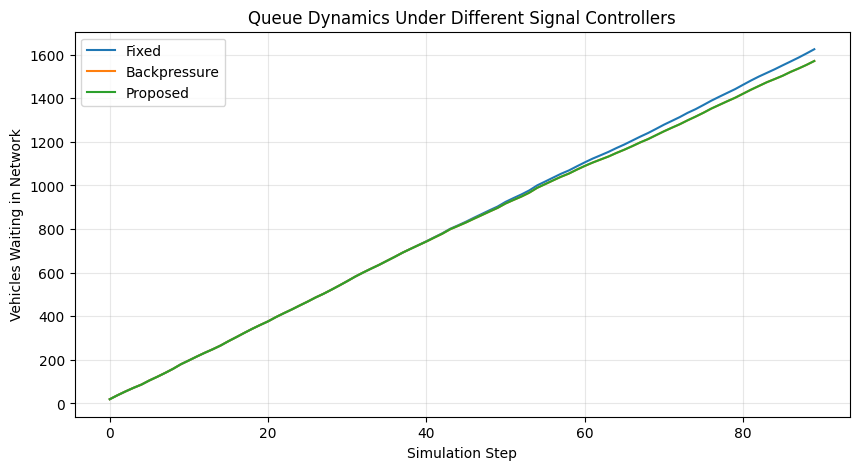

In [ ]:
plt.figure(figsize=(10, 5))
for result in results:
    plt.plot(result["queue_history"], label=result["controller"].title())

plt.xlabel("Simulation Step")
plt.ylabel("Vehicles Waiting in Network")
plt.title("Queue Dynamics Under Different Signal Controllers")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

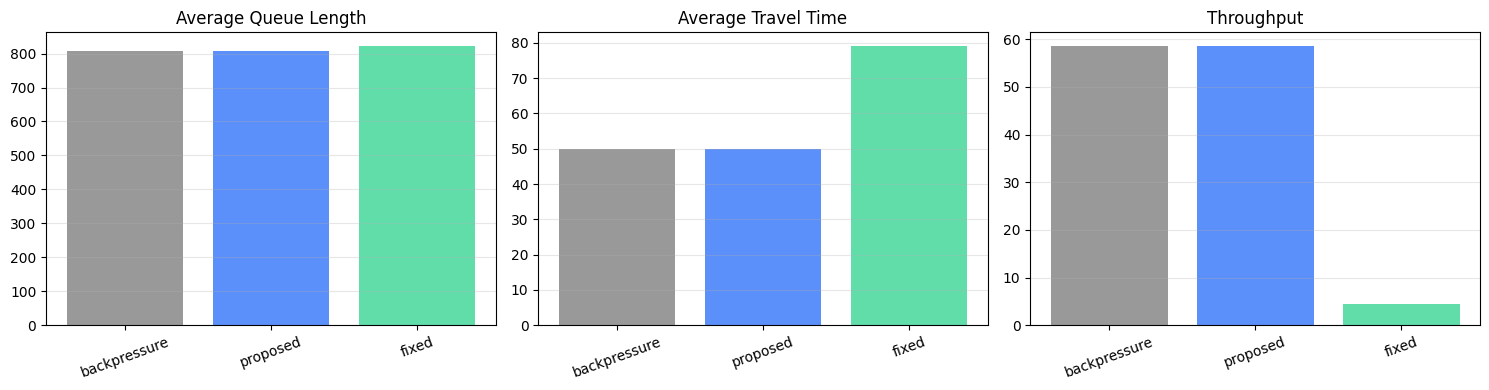

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_columns = [
    ("Average Queue Length", "Average Queue Length"),
    ("Average Travel Time", "Average Travel Time"),
    ("Throughput", "Throughput"),
]

for ax, (column, title) in zip(axes, plot_columns):
    ax.bar(metrics_df["Controller"], metrics_df[column], color=["#999999", "#5B8FF9", "#61DDAA"])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
alpha_values = np.round(np.linspace(0.0, 1.0, 11), 2)
sweep_rows = []

for alpha in alpha_values:
    beta = float(np.round(1.0 - alpha, 2))
    sweep_results, sweep_metrics = evaluate_controllers_over_trials(
        graph=G,
        route_bank=route_bank,
        controllers=["proposed"],
        num_trials=NUM_TRIALS,
        base_seed=RANDOM_SEED,
        alpha=float(alpha),
        beta=beta,
        arrival_rate=ARRIVAL_RATE,
        simulation_steps=SIMULATION_STEPS,
        show_progress=False,
    )

    proposed_row = sweep_metrics.iloc[0]
    sweep_rows.append(
        {
            "alpha": float(alpha),
            "beta": beta,
            "avg_queue": float(proposed_row["Average Queue Length"]),
            "avg_travel_time": float(proposed_row["Average Travel Time"]),
            "throughput": float(proposed_row["Throughput"]),
            "completion_ratio": float(proposed_row["Completion Ratio"]),
        }
    )
    print(f"Completed alpha={alpha:.2f}, beta={beta:.2f}")

alpha_beta_df = pd.DataFrame(sweep_rows).sort_values("alpha").reset_index(drop=True)
alpha_beta_df

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(alpha_beta_df["alpha"], alpha_beta_df["avg_queue"], marker="o", color="#c0392b")
axes[0].set_xlabel("Alpha (load weight)")
axes[0].set_ylabel("Average Queue Length")
axes[0].set_title(f"Proposed Controller Queue vs Alpha ({NUM_TRIALS} Trials)")
axes[0].grid(alpha=0.3)

axes[1].plot(alpha_beta_df["alpha"], alpha_beta_df["avg_travel_time"], marker="o", color="#2e86de")
axes[1].set_xlabel("Alpha (load weight)")
axes[1].set_ylabel("Average Travel Time")
axes[1].set_title(f"Proposed Controller Travel Time vs Alpha ({NUM_TRIALS} Trials)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_queue_idx = alpha_beta_df["avg_queue"].idxmin()
best_queue = alpha_beta_df.loc[best_queue_idx]

print(
    f"Best by queue: alpha={best_queue['alpha']:.2f}, beta={best_queue['beta']:.2f}, "
    f"avg_queue={best_queue['avg_queue']:.2f}, avg_travel_time={best_queue['avg_travel_time']:.2f}"
)

In [ ]:
top_nodes = sorted(
    G.nodes(data=True),
    key=lambda item: item[1].get("betweenness_norm", 0.0),
    reverse=True,
 )[:10]

centrality_df = pd.DataFrame(
    [
        {
            "node": node,
            "betweenness_norm": round(data.get("betweenness_norm", 0.0), 4),
            "in_degree": G.in_degree(node),
            "out_degree": G.out_degree(node),
        }
        for node, data in top_nodes
    ]
 )

centrality_df

,node,betweenness_norm,in_degree,out_degree
0,11505841146,1.0000,2,2
1,858975058,1.0000,2,2
2,21279528,0.8962,4,4
3,196400,0.8407,3,3
4,11505438330,0.8405,2,2
5,11505438295,0.8405,2,2
6,1745361197,0.8405,3,3
7,1745361160,0.8405,3,3
8,11505438328,0.8404,2,2
9,1439230027,0.8403,2,2


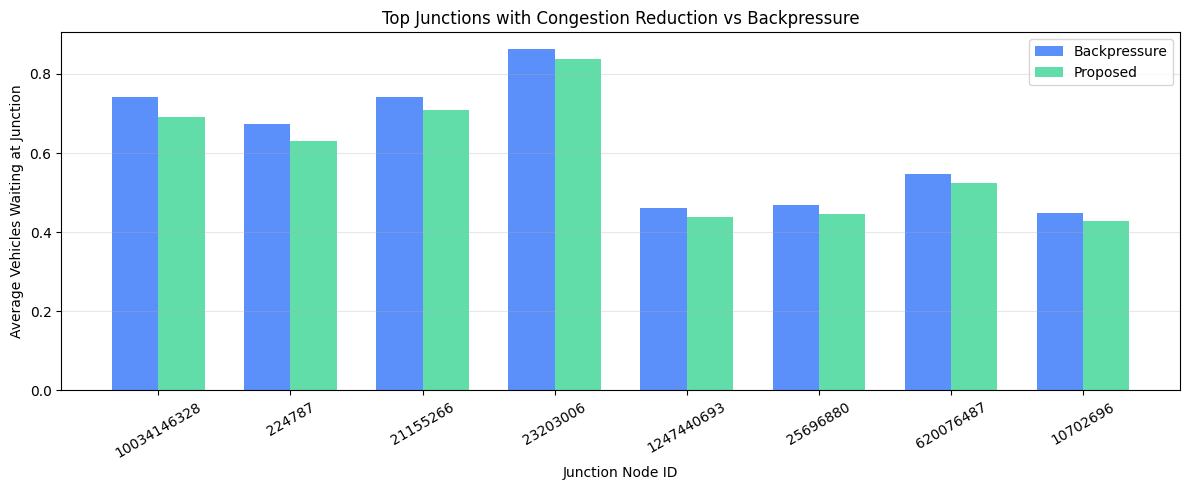

In [ ]:
plot_df = top_junction_improvements.head(8).copy()
plot_df["node"] = plot_df["node"].astype(str)

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(
    x - width / 2,
    plot_df["backpressure_avg_queue"],
    width=width,
    label="Backpressure",
    color="#5B8FF9",
)
plt.bar(
    x + width / 2,
    plot_df["proposed_avg_queue"],
    width=width,
    label="Proposed",
    color="#61DDAA",
)
plt.xticks(x, plot_df["node"], rotation=30)
plt.ylabel("Average Vehicles Waiting at Junction")
plt.xlabel("Junction Node ID")
plt.title("Top Junctions with Congestion Reduction vs Backpressure")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
presentation_df = top_junction_improvements[[
    "node",
    "backpressure_avg_queue",
    "proposed_avg_queue",
    "reduction_vs_backpressure",
]].copy()

for column in [
    "backpressure_avg_queue",
    "proposed_avg_queue",
    "reduction_vs_backpressure",
]:
    presentation_df[column] = presentation_df[column].round(2)

presentation_df.head(5)

,node,backpressure_avg_queue,proposed_avg_queue,reduction_vs_backpressure
125580,10034146328,0.74,0.69,0.05
2618,224787,0.67,0.63,0.04
12100,21155266,0.74,0.71,0.03
15232,23203006,0.86,0.84,0.03
97044,1247440693,0.46,0.44,0.02


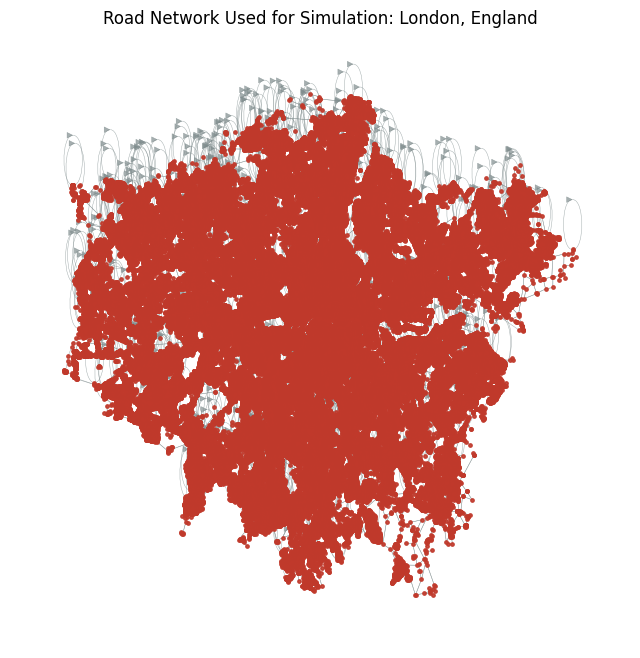

In [ ]:
positions = {
    node: (data["x"], data["y"])
    for node, data in G.nodes(data=True)
}

fig, ax = plt.subplots(figsize=(8, 8))
nx.draw_networkx_edges(
    G,
    pos=positions,
    ax=ax,
    edge_color="#7f8c8d",
    width=0.35,
    alpha=0.7,
    arrows=False,
)
nx.draw_networkx_nodes(
    G,
    pos=positions,
    ax=ax,
    node_size=6,
    node_color="#c0392b",
    alpha=0.9,
)
ax.set_title(f"Road Network Used for Simulation: {PLACE}")
ax.set_axis_off()
plt.show()